In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd

import os
import sys
    
from tqdm import tqdm

from utils.preprocess import *
from torchcfm.conditional_flow_matching import *
from torchcfm.utils import plot_trajectories
from scripts.run_model import *
from simulate.simulate import *
from utils.hydra import *
from omegaconf import OmegaConf

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
dic = {"s": sample_s,
       "s_imbalanced": sample_s_imbalanced,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega,
       "moons": sample_moons,
       }

In [5]:
############################################################

In [6]:
### SETTINGS ###

dataname = "diamond"
size = 5000
d = 2 #dummy dimension

adata = process_fake_data(size, d, dic[dataname])

config = load_config()

OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

config.metric = "cfm"
config.use_wandb = True
config.finsler.use = True
config.finsler.temp = 3.0
config.finsler.lamb = 3.0

project = "ffm-ipynb"

In [7]:
adata

AnnData object with n_obs × n_vars = 5000 × 2
    obs: 'timepoint', 'gene_target', 'cell_type', 'cell_type_one_hot'
    uns: 'std', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [8]:
dataset = extract_paired_dataset(adata)

In [9]:
############################################################

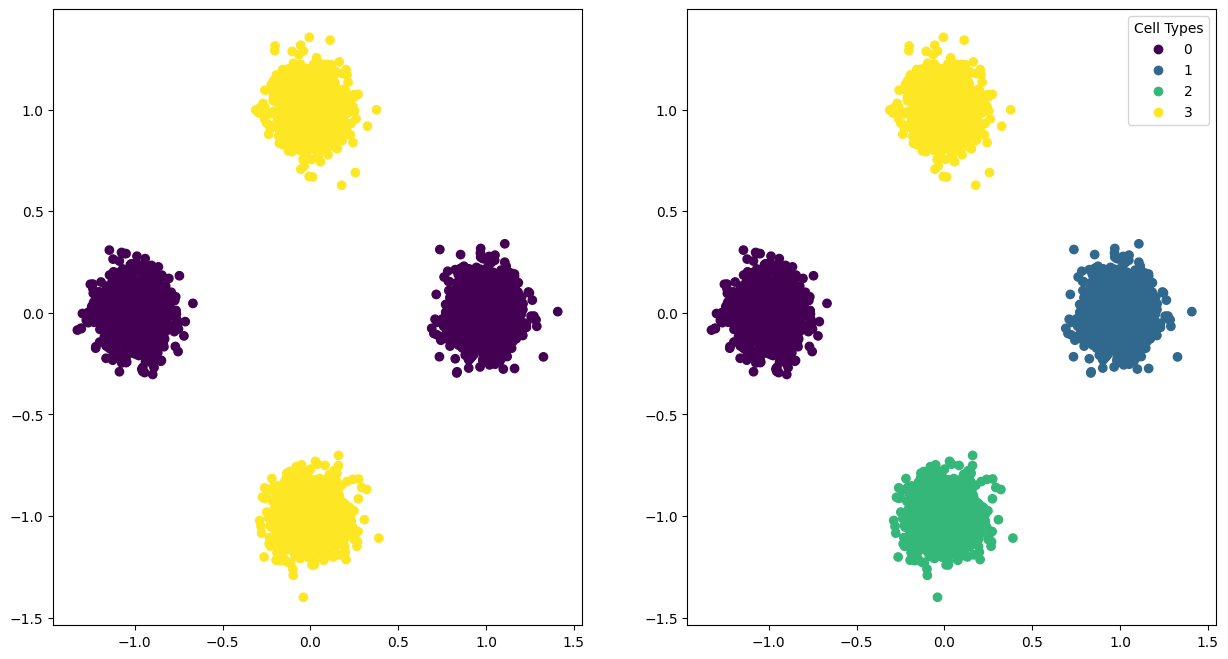

In [10]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
scatter = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [11]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, dataset)

Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

### DEBUG: classifier is constrained to linear ###


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 225 K  | train
1 | geo_net      | SinNet         | 217 K  | train
2 | metric_model | FinslerCFM     | 201 K  | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
443 K     Trainable params
201 K     Non-trainable params
644 K     Total params
2.579     Total estimated

epoch,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇███
train_loss_embed,▆▅▆▂▅▁▄▁▂▂▂▃▆▂▃▄▆▄█▅▅▅▆▅▄▆▄▄▄▅▄▅▇▇█▃▆▇▅▄
train_loss_geo,▁▁▁▁▁▁▁▁▁▂▁▃▂▂▂▁▃▂▃▁▃▁▃▃▁▄▂▃▂▆▂▃▁▃▅▄▄█▅▃
trainer/global_step,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██████
epoch,1999
train_loss_embed,1.29224
train_loss_geo,1.1025
trainer/global_step,1999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 217 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 644 K  | eval 
-----------------------------------------------------------------
217 K     Trainable params
644 K     Non-trainable params
861 K     Total params
3.447     Total estimated model params size (MB)
16        Modules in train mode
5

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,█▄▃▆▃▄▂▂▃▂▂▁▃▂▂▃▃▂▁▂▁▁▂▃▁▁▁▁▂▁▂▂▁▂▁▁▁▂▁▁
trainer/global_step,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇████
epoch,9999
train_loss,0.00207
trainer/global_step,9999


In [12]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

/tmp/ipykernel_217094/2822812520.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipykernel_217094/2822812520.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


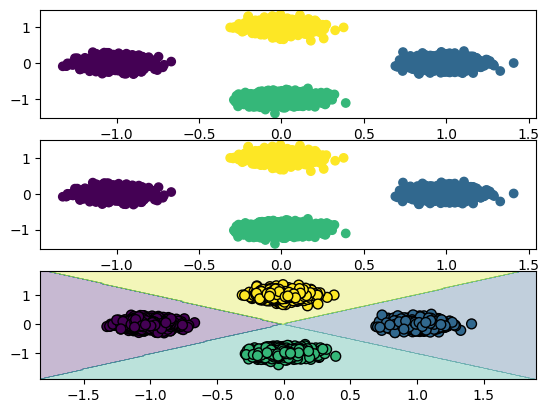

In [13]:
if config.finsler.use:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X).argmax(dim=1)

    fig, axs = plt.subplots(3)
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size for the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)

    with torch.no_grad():
        logits = classifier_model(grid_tensor)
        predictions = torch.argmax(logits, dim=1)

    Z = predictions.cpu().numpy().reshape(xx.shape)
    
    axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')    
    scatter = axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

    plt.show()
    

In [14]:
#NOTE: only works for MFM
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    print(metric_model.M(z.to('cuda')).detach().shape)

    E = metric_model.M(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [15]:
if config.metric == "mfm":
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_metric(metric_model, samples)

In [16]:
from torch.utils.data import DataLoader
from datasets.dataset import *

train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

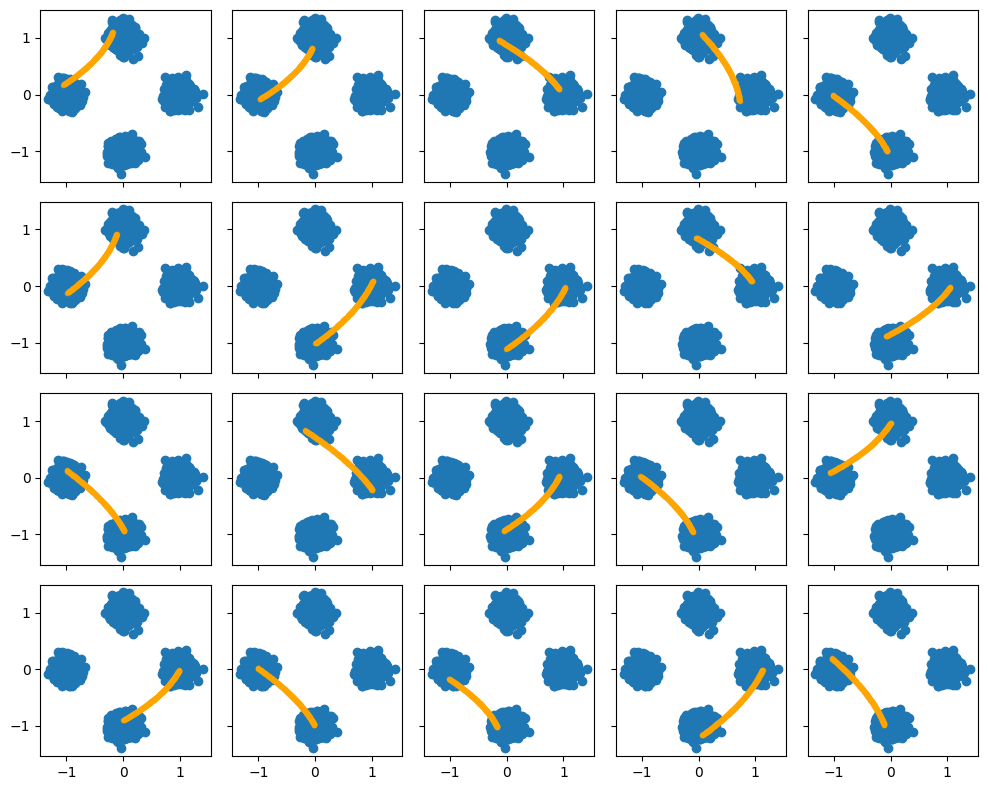

In [17]:
#GEO VALIDATION
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

In [18]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.finsler.use:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

In [19]:
#FLOW VALIDATION

num_samples = 1000
steps = 100

In [20]:
from datasets.dataset import sample
def plot_flow(t0):
    t1 = t0 + 1
    x = adata[adata.obs['timepoint'].astype(int) == t0].obsm['X_pca']
    x = sample(x, min(num_samples, x.shape[0]))
    x = torch.from_numpy(x).float()
    traj = flow_model.sample_traj(x, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [21]:
x = [[-0.5, 0.5]]
v = [[1.0, 1.0]]

x = torch.tensor(x)
v = torch.tensor(v)

# metric_model(x, v)

f_x, Jf_x_v = jvp(metric_model.classifier_fn, (x,), (v,))

u = 1 - f_x @ (metric_model.tree.to(metric_model.get_device()) + torch.eye(f_x.shape[-1], device=x.device))

# D = self.fisher_rao(x)
D = torch.ones_like(f_x)

finsler_term = torch.sum(Jf_x_v * D * u, dim=-1)
finsler_term = F.relu(finsler_term)
print(f_x)
print(Jf_x_v)
print(u)
print(finsler_term)

tensor([[0.5039, 0.0022, 0.0025, 0.4914]])
tensor([[-2.6518,  0.0119, -0.0135,  2.6533]])
tensor([[0.4961, 0.9978, 0.4936, 0.5064]])
tensor([0.0336])


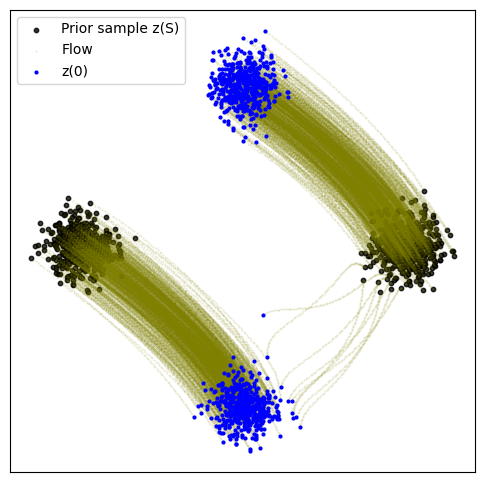

In [22]:
plot_flow(0)

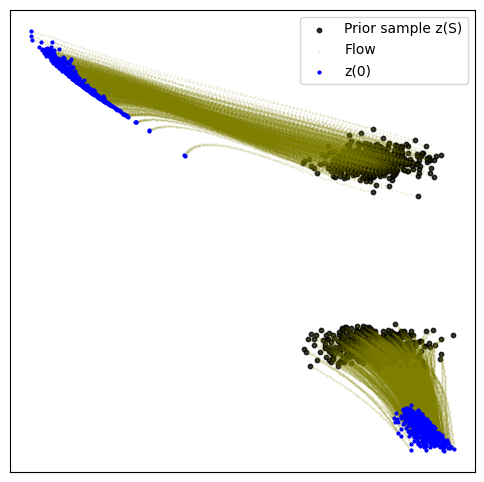

In [23]:
plot_flow(1)


In [24]:
plot_flow(2)

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
plot_flow(3)

In [ ]:
plot_flow(4)